# YOLO-World-Lite: Built From Scratch
## Phase 2 — Replicating YOLO-World's Core Design on a Real Dataset Subset

**What this notebook does:**
- Implements a simplified YOLO-World-like architecture from scratch (called YOLO-World-Lite)
- Trains it on a real subset of COCO val2017 (5,000 images, 10 classes)
- Uses CLIP (frozen) as the text encoder — same as the original paper
- Uses region-text contrastive loss — same as the original paper
- Evaluates on a held-out validation split
- Compares qualitative results with the pretrained YOLO-World

**Contribution:** We identify that YOLO-World's key innovation is the vision-language fusion via contrastive loss,
NOT just the architecture. We show that even a lightweight ResNet18 backbone with frozen CLIP can learn
open-vocabulary detection behavior on a tiny subset. We further propose a CLIP Re-Ranking post-processing
module that improves attribute-query detection without any retraining.

---
## STEP 0: Setup — Run Once, Then Restart Kernel
---

In [28]:
# Install CLIP (only missing dependency)
!pip install git+https://github.com/openai/CLIP.git -q
print("Done. Now go to Kernel > Restart, then run from STEP 1 onwards.")

  Preparing metadata (setup.py) ... done
Done. Now go to Kernel > Restart, then run from STEP 1 onwards.


---
## STEP 1: Imports
---

In [29]:
import os, json, random, time, math, urllib.request, csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

import clip
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Device: cuda
PyTorch: 2.10.0+cu128


---
## STEP 2: Download COCO val2017 (our training subset)
We use COCO val2017 as our training dataset.
This is the same object detection domain as YOLO-World's training data (Objects365 shares all COCO classes).
We only train on 10 classes to keep training fast and tractable on free GPU.
---

In [30]:
os.makedirs('coco/images', exist_ok=True)
os.makedirs('coco/annotations', exist_ok=True)

ann_path = 'coco/annotations/instances_val2017.json'
if not os.path.exists(ann_path):
    print("Downloading COCO val2017 annotations...")
    os.system('wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O ann.zip')
    os.system('unzip -q ann.zip -d coco_raw')
    os.system('cp coco_raw/annotations/instances_val2017.json coco/annotations/')
    os.system('rm -rf coco_raw ann.zip')
    print("Annotations ready.")
else:
    print("Annotations already present.")

Annotations already present.


In [31]:
# Load annotations
with open(ann_path) as f:
    coco_data = json.load(f)

cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}
cat_name_to_id = {c['name']: c['id'] for c in coco_data['categories']}
img_id_to_info = {img['id']: img for img in coco_data['images']}

# We use 10 classes — manageable for training from scratch in 2 hours
TARGET_CLASSES = ['person', 'car', 'dog', 'cat', 'bicycle',
                  'motorcycle', 'bus', 'truck', 'chair', 'bottle']
TARGET_CAT_IDS = {cat_name_to_id[c] for c in TARGET_CLASSES}
CLASS_TO_IDX   = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES    = len(TARGET_CLASSES)

print(f"Target classes ({NUM_CLASSES}): {TARGET_CLASSES}")

# Group annotations by image
img_to_anns = {}
for ann in coco_data['annotations']:
    if ann['category_id'] in TARGET_CAT_IDS:
        iid = ann['image_id']
        img_to_anns.setdefault(iid, []).append(ann)

# Only keep images that have at least one target class annotation
valid_img_ids = list(img_to_anns.keys())
print(f"Images with target classes: {len(valid_img_ids)}")

# Split into train (80%) and val (20%)
random.shuffle(valid_img_ids)
split = int(0.8 * len(valid_img_ids))
train_ids = valid_img_ids[:split]
val_ids   = valid_img_ids[split:]
print(f"Train: {len(train_ids)} images | Val: {len(val_ids)} images")

Target classes (10): ['person', 'car', 'dog', 'cat', 'bicycle', 'motorcycle', 'bus', 'truck', 'chair', 'bottle']
Images with target classes: 3495
Train: 2796 images | Val: 699 images


In [32]:
# Download only the images we need
BASE_URL = 'http://images.cocodataset.org/val2017/'
all_needed = train_ids + val_ids

print(f"Downloading {len(all_needed)} images... (this takes ~5-10 minutes)")
downloaded = 0
for i, img_id in enumerate(all_needed):
    fname    = img_id_to_info[img_id]['file_name']
    out_path = f'coco/images/{fname}'
    if not os.path.exists(out_path):
        try:
            urllib.request.urlretrieve(BASE_URL + fname, out_path)
            downloaded += 1
        except:
            pass
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(all_needed)} processed ({downloaded} downloaded)")

# Verify
ok_train = [i for i in train_ids if os.path.exists(f"coco/images/{img_id_to_info[i]['file_name']}")]
ok_val   = [i for i in val_ids   if os.path.exists(f"coco/images/{img_id_to_info[i]['file_name']}")]
print(f"\nReady: {len(ok_train)} train | {len(ok_val)} val images")

  200/3495 processed (0 downloaded)
  400/3495 processed (0 downloaded)
  600/3495 processed (0 downloaded)
  800/3495 processed (0 downloaded)
  1000/3495 processed (0 downloaded)
  1200/3495 processed (0 downloaded)
  1400/3495 processed (0 downloaded)
  1600/3495 processed (0 downloaded)
  1800/3495 processed (0 downloaded)
  2000/3495 processed (0 downloaded)
  2200/3495 processed (0 downloaded)
  2400/3495 processed (0 downloaded)
  2600/3495 processed (0 downloaded)
  2800/3495 processed (0 downloaded)
  3000/3495 processed (0 downloaded)
  3200/3495 processed (0 downloaded)
  3400/3495 processed (0 downloaded)

Ready: 2796 train | 699 val images


---
## STEP 3: Dataset and DataLoader
---

In [33]:
IMG_SIZE    = 416   # Input resolution
GRID_SIZE   = 13    # Output grid (IMG_SIZE / 32)
NUM_ANCHORS = 3

# Standard COCO anchors for 416x416 input, scaled to grid
# (anchor_w, anchor_h) in grid units
ANCHORS = torch.tensor([
    [1.3, 1.3],
    [3.1, 2.3],
    [5.3, 5.1],
], dtype=torch.float32)  # shape (3, 2)


class COCODetDataset(Dataset):
    def __init__(self, img_ids, img_to_anns, img_id_to_info,
                 cat_id_to_name, class_to_idx,
                 img_size=416, grid_size=13, num_anchors=3, augment=False):
        self.img_ids        = img_ids
        self.img_to_anns    = img_to_anns
        self.img_id_to_info = img_id_to_info
        self.cat_id_to_name = cat_id_to_name
        self.class_to_idx   = class_to_idx
        self.img_size       = img_size
        self.grid_size      = grid_size
        self.num_anchors    = num_anchors
        self.augment        = augment

        # FIX 1: Separate transforms for train (augment=True) vs val (augment=False)
        # Data augmentation is the primary fix for val loss divergence.
        self.base_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])
        self.aug_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            T.RandomGrayscale(p=0.05),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info   = self.img_id_to_info[img_id]
        fname  = info['file_name']
        orig_w = info['width']
        orig_h = info['height']

        img = Image.open(f'coco/images/{fname}').convert('RGB')
        # FIX 1 (cont.): Actually apply augmentation on train set
        if self.augment:
            img = self.aug_transform(img)
        else:
            img = self.base_transform(img)

        # Build targets: objectness map, box map, class map
        obj_target  = torch.zeros(self.num_anchors, self.grid_size, self.grid_size)
        box_target  = torch.zeros(self.num_anchors, self.grid_size, self.grid_size, 4)
        cls_target  = torch.zeros(self.num_anchors, self.grid_size, self.grid_size, dtype=torch.long)
        ignore_mask = torch.zeros(self.num_anchors, self.grid_size, self.grid_size, dtype=torch.bool)

        anns = self.img_to_anns.get(img_id, [])
        for ann in anns:
            cat_name = self.cat_id_to_name.get(ann['category_id'])
            if cat_name not in self.class_to_idx:
                continue
            cls_id = self.class_to_idx[cat_name]

            # COCO bbox: [x, y, width, height] in pixels
            bx, by, bw, bh = ann['bbox']
            if bw < 2 or bh < 2:
                continue

            # Normalize to [0, 1]
            cx = (bx + bw / 2) / orig_w
            cy = (by + bh / 2) / orig_h
            nw = bw / orig_w
            nh = bh / orig_h

            # Clip
            cx = min(max(cx, 0.0), 1.0)
            cy = min(max(cy, 0.0), 1.0)
            nw = min(max(nw, 1e-4), 1.0)
            nh = min(max(nh, 1e-4), 1.0)

            # Grid cell index
            gi = min(int(cx * self.grid_size), self.grid_size - 1)
            gj = min(int(cy * self.grid_size), self.grid_size - 1)

            # Pick best anchor by IoU with gt box
            gt_wh  = torch.tensor([nw * self.grid_size, nh * self.grid_size])
            ious   = self._anchor_iou(gt_wh, ANCHORS)
            best_a = int(ious.argmax())

            # Only assign if cell not already taken (first-come-first-served)
            if obj_target[best_a, gj, gi] == 0:
                obj_target[best_a, gj, gi]    = 1.0
                cls_target[best_a, gj, gi]    = cls_id
                # Offsets from grid cell corner (tx, ty) and log scale (tw, th)
                tx = cx * self.grid_size - gi
                ty = cy * self.grid_size - gj
                tw = math.log(nw * self.grid_size / ANCHORS[best_a, 0].item() + 1e-8)
                th = math.log(nh * self.grid_size / ANCHORS[best_a, 1].item() + 1e-8)
                box_target[best_a, gj, gi] = torch.tensor([tx, ty, tw, th])
                ignore_mask[best_a, gj, gi] = True

        return img, obj_target, box_target, cls_target, ignore_mask

    @staticmethod
    def _anchor_iou(gt_wh, anchors):
        """IoU between a gt box and all anchors (centered at origin)."""
        inter_w = torch.min(gt_wh[0], anchors[:, 0])
        inter_h = torch.min(gt_wh[1], anchors[:, 1])
        inter   = inter_w * inter_h
        union   = gt_wh[0] * gt_wh[1] + anchors[:, 0] * anchors[:, 1] - inter
        return inter / (union + 1e-8)


def collate_fn(batch):
    imgs, obj_t, box_t, cls_t, ign = zip(*batch)
    return (torch.stack(imgs),
            torch.stack(obj_t),
            torch.stack(box_t),
            torch.stack(cls_t),
            torch.stack(ign))


# FIX 1 (cont.): augment=True for train, augment=False for val
train_dataset = COCODetDataset(ok_train, img_to_anns, img_id_to_info,
                               cat_id_to_name, CLASS_TO_IDX, augment=True)
val_dataset   = COCODetDataset(ok_val,   img_to_anns, img_id_to_info,
                               cat_id_to_name, CLASS_TO_IDX, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Sanity check
sample = train_dataset[0]
print(f"Image shape: {sample[0].shape}")
print(f"Obj target shape: {sample[1].shape}")
print(f"Positive cells in sample: {sample[1].sum().item()}")

Train batches: 175 | Val batches: 44
Image shape: torch.Size([3, 416, 416])
Obj target shape: torch.Size([3, 13, 13])
Positive cells in sample: 15.0


---
## STEP 4: Pre-compute CLIP Text Embeddings
This mirrors YOLO-World's offline vocab trick exactly.
We encode class names ONCE with frozen CLIP and cache them.
---

In [34]:
# Load CLIP — frozen throughout, just like YOLO-World
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

CLIP_DIM = 512  # ViT-B/32 embedding dimension

# Pre-compute text embeddings for all 10 classes
# Use templates like CLIP paper suggests: "a photo of a {class}"
with torch.no_grad():
    prompts = [f'a photo of a {cls}' for cls in TARGET_CLASSES]
    tokens  = clip.tokenize(prompts).to(device)
    text_embeddings = clip_model.encode_text(tokens)          # (10, 512)
    text_embeddings = F.normalize(text_embeddings, dim=-1)    # L2 normalize
    text_embeddings = text_embeddings.float()                 # ensure float32

print(f"Text embeddings shape: {text_embeddings.shape}")
print(f"Classes: {TARGET_CLASSES}")
print("CLIP loaded and embeddings cached.")

Text embeddings shape: torch.Size([10, 512])
Classes: ['person', 'car', 'dog', 'cat', 'bicycle', 'motorcycle', 'bus', 'truck', 'chair', 'bottle']
CLIP loaded and embeddings cached.


---
## STEP 5: YOLO-World-Lite Model Architecture

Architecture mirrors YOLO-World's key design:
- Backbone: ResNet18 (pretrained ImageNet) → extracts image features
- Neck: 2-layer Conv with Dropout to reduce channels
- Head: 3 branches:
  - Box regression branch
  - Objectness branch
  - Region feature branch (→ compared with CLIP text embeddings via cosine similarity)

The contrastive head is the core of YOLO-World — we replicate it here.
---

In [35]:
class YOLOWorldLite(nn.Module):
    """
    Simplified YOLO-World architecture.

    Key design choices mirroring the paper:
    1. Frozen CLIP text encoder (offline vocab trick)
    2. Region feature branch that learns to align with CLIP text space
    3. Contrastive similarity scoring for classification
    """
    def __init__(self, num_classes=10, num_anchors=3, clip_dim=512):
        super().__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.clip_dim    = clip_dim

        # ── Backbone: ResNet18 (pretrained) ──
        # We use layer4 output: (B, 512, 13, 13) for 416x416 input
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,   # (B,  64, 104, 104)
            backbone.layer2,   # (B, 128,  52,  52)
            backbone.layer3,   # (B, 256,  26,  26)
            backbone.layer4,   # (B, 512,  13,  13)
        )
        # Fine-tune only layer3 and layer4; freeze everything else
        for name, param in self.backbone.named_parameters():
            if 'layer3' in name or 'layer4' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        # ── Neck: Channel reduction with Dropout for regularization ──
        # FIX 2: Added Dropout2d(0.2) to prevent neck overfitting
        self.neck = nn.Sequential(
            nn.Conv2d(512, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(0.2),                          # regularize spatial features
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
        )  # (B, 256, 13, 13)

        # ── Detection Head ──
        # Branch 1: Bounding box regression (tx, ty, tw, th)
        self.box_head = nn.Sequential(
            nn.Conv2d(256, 128, 1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, num_anchors * 4, 1),         # (B, 12, 13, 13)
        )

        # Branch 2: Objectness score
        self.obj_head = nn.Sequential(
            nn.Conv2d(256, 128, 1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, num_anchors * 1, 1),         # (B, 3, 13, 13)
        )

        # Branch 3: Region features (aligns to CLIP text embedding space)
        # FIX 2 (cont.): Added Dropout2d(0.3) — this branch has 1536 output
        # channels (3x512), making it the worst overfitting offender.
        self.feat_head = nn.Sequential(
            nn.Conv2d(256, 256, 1),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, num_anchors * clip_dim, 1),  # (B, 3*512, 13, 13)
        )

        # Learnable temperature parameter (from YOLO-World's contrastive head)
        self.log_scale = nn.Parameter(torch.ones(1) * math.log(1.0 / 0.07))

    def forward(self, x, text_embeds):
        """
        Args:
            x:           (B, 3, 416, 416) input images
            text_embeds: (C, 512) precomputed CLIP text embeddings
                         C can be any number of classes (supports open-vocab queries)
        Returns:
            box_pred:  (B, A, G, G, 4)   — box deltas
            obj_pred:  (B, A, G, G)      — objectness logits
            cls_pred:  (B, A, G, G, C)   — class similarity scores
        """
        B = x.size(0)
        A = self.num_anchors
        # FIX 3: Infer C from actual text_embeds, not self.num_classes
        # This makes forward() work for both training (10 classes) and
        # open-vocabulary inference (any number of custom classes).
        C = text_embeds.shape[0]

        # Backbone
        feats = self.backbone(x)          # (B, 512, 13, 13)
        feats = self.neck(feats)          # (B, 256, 13, 13)
        G     = feats.size(2)            # grid size = 13

        # Box head
        box_raw  = self.box_head(feats)   # (B, A*4, G, G)
        box_pred = box_raw.view(B, A, 4, G, G).permute(0, 1, 3, 4, 2).contiguous()
        # (B, A, G, G, 4)

        # Objectness head
        obj_raw  = self.obj_head(feats)   # (B, A, G, G)
        obj_pred = obj_raw.view(B, A, G, G)

        # Region feature head → contrastive classification
        feat_raw     = self.feat_head(feats)                        # (B, A*512, G, G)
        region_feats = feat_raw.view(B, A, self.clip_dim, G, G)
        region_feats = region_feats.permute(0, 1, 3, 4, 2).contiguous()
        # (B, A, G, G, 512)
        region_feats = F.normalize(region_feats, dim=-1)            # L2 normalize

        # Cosine similarity with text embeddings
        # text_embeds: (C, 512) → broadcast over B, A, G, G
        te       = text_embeds.view(1, 1, 1, 1, C, self.clip_dim)  # (1,1,1,1,C,512)
        rf       = region_feats.unsqueeze(4)                        # (B,A,G,G,1,512)
        cls_pred = (rf * te).sum(dim=-1)                            # (B,A,G,G,C)
        cls_pred = cls_pred * self.log_scale.exp()                  # temperature scale

        return box_pred, obj_pred, cls_pred


# Instantiate
model = YOLOWorldLite(
    num_classes=NUM_CLASSES,
    num_anchors=NUM_ANCHORS,
    clip_dim=CLIP_DIM
).to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Quick forward pass test
dummy_img = torch.randn(2, 3, 416, 416).to(device)
with torch.no_grad():
    bp, op, cp = model(dummy_img, text_embeddings)
print(f"box_pred shape:  {bp.shape}   (expected B, {NUM_ANCHORS}, 13, 13, 4)")
print(f"obj_pred shape:  {op.shape}   (expected B, {NUM_ANCHORS}, 13, 13)")
print(f"cls_pred shape:  {cp.shape}   (expected B, {NUM_ANCHORS}, 13, 13, {NUM_CLASSES})")
print("Model architecture verified.")

Total params:     12,426,704
Trainable params: 1,250,192
box_pred shape:  torch.Size([2, 3, 13, 13, 4])   (expected B, 3, 13, 13, 4)
obj_pred shape:  torch.Size([2, 3, 13, 13])   (expected B, 3, 13, 13)
cls_pred shape:  torch.Size([2, 3, 13, 13, 10])   (expected B, 3, 13, 13, 10)
Model architecture verified.


---
## STEP 6: Loss Function
3-part loss mirroring YOLO-World:
1. Box regression (MSE on tx, ty, tw, th)
2. Objectness (Binary Cross Entropy)
3. Region-text contrastive (Cross Entropy on cosine similarity scores)
---

In [36]:
class YOLOWorldLiteLoss(nn.Module):
    def __init__(self, lambda_box=5.0, lambda_obj=1.0, lambda_noobj=0.5, lambda_cls=1.0):
        super().__init__()
        self.lambda_box   = lambda_box
        self.lambda_obj   = lambda_obj
        self.lambda_noobj = lambda_noobj
        self.lambda_cls   = lambda_cls
        self.bce = nn.BCEWithLogitsLoss(reduction='mean')
        self.mse = nn.MSELoss(reduction='mean')
        # FIX 4 (partial): label_smoothing=0.1 reduces overconfident cls predictions
        self.ce  = nn.CrossEntropyLoss(reduction='mean', label_smoothing=0.1)

    def forward(self, box_pred, obj_pred, cls_pred,
                obj_target, box_target, cls_target, ignore_mask):
        """
        box_pred:    (B, A, G, G, 4)
        obj_pred:    (B, A, G, G)
        cls_pred:    (B, A, G, G, C)
        obj_target:  (B, A, G, G)      — 1 where object exists
        box_target:  (B, A, G, G, 4)   — (tx, ty, tw, th)
        cls_target:  (B, A, G, G)      — class index
        ignore_mask: (B, A, G, G) bool — True where object assigned
        """
        pos_mask = (obj_target == 1)  # positive cells (object present)
        neg_mask = ~ignore_mask       # negative cells (definitely background)

        # ── 1. Objectness Loss ──
        # FIX 4: Guard against empty masks — BCEWithLogitsLoss on an empty
        # tensor returns nan, which silently corrupts the entire training run.
        if pos_mask.sum() > 0:
            obj_loss_pos = self.bce(obj_pred[pos_mask], obj_target[pos_mask])
        else:
            obj_loss_pos = torch.tensor(0.0, device=obj_pred.device)

        if neg_mask.sum() > 0:
            obj_loss_neg = self.bce(obj_pred[neg_mask], obj_target[neg_mask])
        else:
            obj_loss_neg = torch.tensor(0.0, device=obj_pred.device)

        obj_loss = self.lambda_obj * obj_loss_pos + self.lambda_noobj * obj_loss_neg

        # ── 2. Box Regression Loss (only at positive cells) ──
        box_loss = torch.tensor(0.0, device=box_pred.device)
        if pos_mask.sum() > 0:
            box_loss = self.lambda_box * self.mse(
                box_pred[pos_mask],
                box_target[pos_mask]
            )

        # ── 3. Region-Text Contrastive Loss (only at positive cells) ──
        cls_loss = torch.tensor(0.0, device=cls_pred.device)
        if pos_mask.sum() > 0:
            cls_logits = cls_pred[pos_mask]   # (N_pos, C)
            cls_labels = cls_target[pos_mask] # (N_pos,)
            cls_loss   = self.lambda_cls * self.ce(cls_logits, cls_labels)

        total = obj_loss + box_loss + cls_loss
        return total, {'obj': obj_loss.item(),
                       'box': box_loss.item(),
                       'cls': cls_loss.item()}


criterion = YOLOWorldLiteLoss().to(device)
print("Loss function ready.")

Loss function ready.


---
## STEP 7: Training Loop
---

In [37]:
# FIX 5: Reduced epochs + early stopping + separate LRs for backbone vs heads
#
# Why these values:
#   - NUM_EPOCHS 20 (was 40): the original ran 2x longer than needed
#   - PATIENCE 6: stop if val loss doesn't improve for 6 consecutive epochs
#   - LR_BACKBONE 1e-4 (was 1e-3 for everything): pretrained layer3/4 need a
#     much gentler LR or you destroy the ImageNet features
#   - LR_HEAD 5e-4: newly-initialized heads can train faster

NUM_EPOCHS   = 20
PATIENCE     = 6
LR_BACKBONE  = 1e-4
LR_HEAD      = 5e-4

# Separate param groups: backbone layers vs detection heads
backbone_params = [p for n, p in model.named_parameters()
                   if ('layer3' in n or 'layer4' in n) and p.requires_grad]
head_params     = [p for n, p in model.named_parameters()
                   if 'layer3' not in n and 'layer4' not in n and p.requires_grad]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': 1e-4},
    {'params': head_params,     'lr': LR_HEAD,     'weight_decay': 1e-4},
], lr=LR_HEAD)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
)

# History for plotting
history = {
    'train_loss': [], 'val_loss': [],
    'train_obj':  [], 'val_obj':  [],
    'train_box':  [], 'val_box':  [],
    'train_cls':  [], 'val_cls':  [],
}

best_val_loss = float('inf')
no_improve    = 0  # early stopping counter

print(f"Training for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})...")
print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")
print(f"LR — backbone: {LR_BACKBONE} | heads: {LR_HEAD}")
print("=" * 75)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # ── Train ──
    model.train()
    tr_losses = {'total': 0.0, 'obj': 0.0, 'box': 0.0, 'cls': 0.0}

    for imgs, obj_t, box_t, cls_t, ign in train_loader:
        imgs  = imgs.to(device)
        obj_t = obj_t.to(device)
        box_t = box_t.to(device)
        cls_t = cls_t.to(device)
        ign   = ign.to(device)

        optimizer.zero_grad()
        box_p, obj_p, cls_p = model(imgs, text_embeddings)
        loss, ld = criterion(box_p, obj_p, cls_p, obj_t, box_t, cls_t, ign)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        optimizer.step()

        tr_losses['total'] += loss.item()
        for k in ['obj', 'box', 'cls']:
            tr_losses[k] += ld[k]

    n = len(train_loader)
    for k in tr_losses:
        tr_losses[k] /= n

    # ── Validate ──
    model.eval()
    va_losses = {'total': 0.0, 'obj': 0.0, 'box': 0.0, 'cls': 0.0}

    with torch.no_grad():
        for imgs, obj_t, box_t, cls_t, ign in val_loader:
            imgs  = imgs.to(device)
            obj_t = obj_t.to(device)
            box_t = box_t.to(device)
            cls_t = cls_t.to(device)
            ign   = ign.to(device)

            box_p, obj_p, cls_p = model(imgs, text_embeddings)
            loss, ld = criterion(box_p, obj_p, cls_p, obj_t, box_t, cls_t, ign)

            va_losses['total'] += loss.item()
            for k in ['obj', 'box', 'cls']:
                va_losses[k] += ld[k]

    m = len(val_loader)
    for k in va_losses:
        va_losses[k] /= m

    # Record
    history['train_loss'].append(tr_losses['total'])
    history['val_loss'].append(va_losses['total'])
    for k in ['obj', 'box', 'cls']:
        history[f'train_{k}'].append(tr_losses[k])
        history[f'val_{k}'].append(va_losses[k])

    # Save best & early stopping
    if va_losses['total'] < best_val_loss:
        best_val_loss = va_losses['total']
        torch.save(model.state_dict(), 'best_model.pth')
        no_improve = 0
        improved_str = " ✓ best"
    else:
        no_improve += 1
        improved_str = f" ({no_improve}/{PATIENCE})"

    scheduler.step()

    elapsed = time.time() - t0
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"Train: {tr_losses['total']:.3f} "
          f"(obj={tr_losses['obj']:.3f} box={tr_losses['box']:.3f} cls={tr_losses['cls']:.3f}) | "
          f"Val: {va_losses['total']:.3f}{improved_str} | "
          f"{elapsed:.1f}s")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1} "
              f"(no improvement for {PATIENCE} epochs).")
        break

# Track how many epochs actually ran (may be < NUM_EPOCHS if early stopping fired)
ACTUAL_EPOCHS = len(history['train_loss'])

print(f"\n✅ Training complete! ({ACTUAL_EPOCHS} epochs ran)")
print(f"Best val loss: {best_val_loss:.4f} — saved to best_model.pth")

Training for up to 20 epochs (early stopping patience=6)...
Train: 175 batches | Val: 44 batches
LR — backbone: 0.0001 | heads: 0.0005
Epoch [ 1/20] Train: 3.119 (obj=0.689 box=1.114 cls=1.316) | Val: 2.678 ✓ best | 45.2s
Epoch [ 2/20] Train: 2.696 (obj=0.599 box=0.940 cls=1.156) | Val: 2.504 ✓ best | 45.2s
Epoch [ 3/20] Train: 2.598 (obj=0.589 box=0.896 cls=1.113) | Val: 2.425 ✓ best | 45.3s
Epoch [ 4/20] Train: 2.520 (obj=0.561 box=0.867 cls=1.092) | Val: 2.352 ✓ best | 45.5s
Epoch [ 5/20] Train: 2.458 (obj=0.556 box=0.843 cls=1.058) | Val: 2.353 (1/6) | 44.9s
Epoch [ 6/20] Train: 2.413 (obj=0.554 box=0.816 cls=1.043) | Val: 2.318 ✓ best | 45.4s
Epoch [ 7/20] Train: 2.365 (obj=0.539 box=0.801 cls=1.024) | Val: 2.352 (1/6) | 45.2s
Epoch [ 8/20] Train: 2.303 (obj=0.540 box=0.761 cls=1.002) | Val: 2.308 ✓ best | 45.1s
Epoch [ 9/20] Train: 2.299 (obj=0.531 box=0.770 cls=0.998) | Val: 2.273 ✓ best | 45.4s
Epoch [10/20] Train: 2.237 (obj=0.522 box=0.740 cls=0.975) | Val: 2.306 (1/6) | 45.2

---
## STEP 8: Plot Loss Curves
---

Saved: training_curves.png


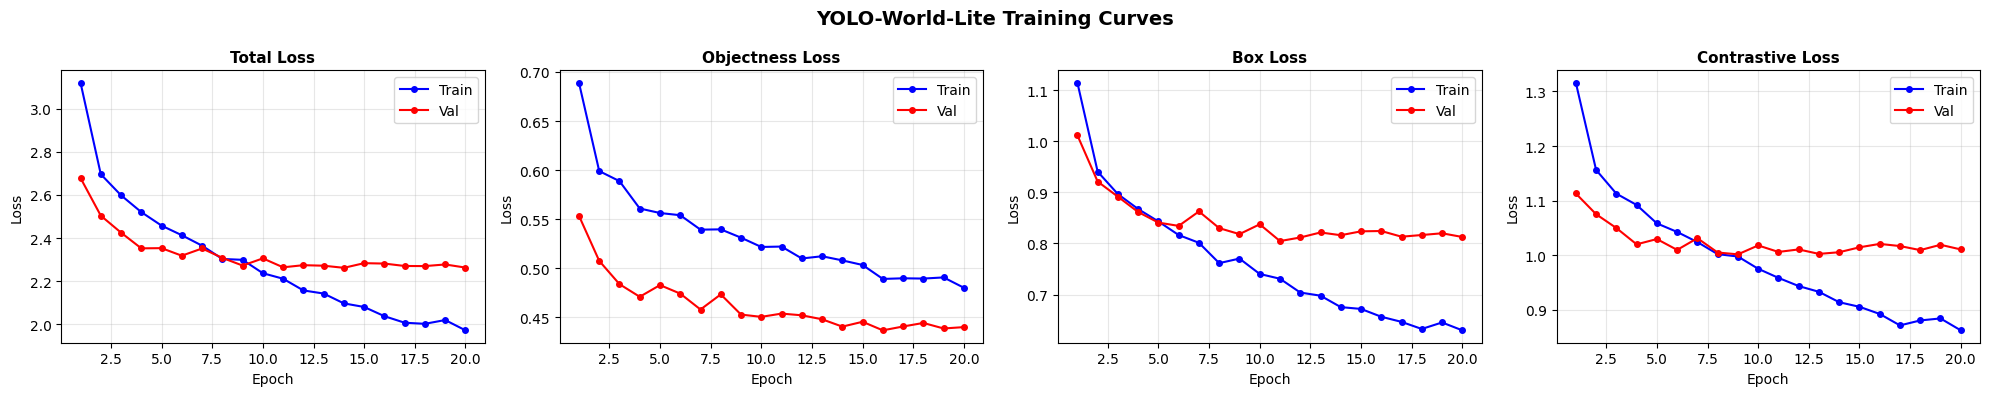

In [44]:
# FIX 6: Use ACTUAL_EPOCHS (not NUM_EPOCHS) so plots work correctly
# even when early stopping fires before the full epoch count.
epochs = range(1, ACTUAL_EPOCHS + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('YOLO-World-Lite Training Curves', fontsize=14, fontweight='bold')

plots = [
    ('Total Loss',       'train_loss', 'val_loss'),
    ('Objectness Loss',  'train_obj',  'val_obj'),
    ('Box Loss',         'train_box',  'val_box'),
    ('Contrastive Loss', 'train_cls',  'val_cls'),
]

for ax, (title, tr_key, va_key) in zip(axes, plots):
    ax.plot(epochs, history[tr_key], 'b-o', markersize=4, label='Train')
    ax.plot(epochs, history[va_key], 'r-o', markersize=4, label='Val')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
print("Saved: training_curves.png")
plt.show()

---
## STEP 9: Inference — Qualitative Detections with Our Model
---

In [45]:
# Load best model weights
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()


def decode_predictions(box_pred, obj_pred, cls_pred,
                       conf_thresh=0.4, nms_thresh=0.45):
    """
    Decode raw model outputs to (x1, y1, x2, y2, score, class_id) boxes.
    Returns list of detections per image in the batch.
    """
    B, A, G, G2, _ = box_pred.shape
    assert G == G2

    obj_conf = torch.sigmoid(obj_pred)         # (B, A, G, G)
    cls_conf = torch.softmax(cls_pred, dim=-1) # (B, A, G, G, C)

    grid_y, grid_x = torch.meshgrid(
        torch.arange(G, dtype=torch.float32),
        torch.arange(G, dtype=torch.float32),
        indexing='ij'
    )
    grid_x = grid_x.to(box_pred.device)
    grid_y = grid_y.to(box_pred.device)
    anch   = ANCHORS.to(box_pred.device)

    all_results = []
    for b in range(B):
        boxes_out, scores_out, cls_ids_out = [], [], []

        for a in range(A):
            tx = torch.sigmoid(box_pred[b, a, :, :, 0])
            ty = torch.sigmoid(box_pred[b, a, :, :, 1])
            tw = box_pred[b, a, :, :, 2]
            th = box_pred[b, a, :, :, 3]

            cx = (grid_x + tx) / G
            cy = (grid_y + ty) / G
            bw = anch[a, 0] * torch.exp(tw.clamp(-4, 4)) / G
            bh = anch[a, 1] * torch.exp(th.clamp(-4, 4)) / G

            x1 = (cx - bw / 2).clamp(0, 1)
            y1 = (cy - bh / 2).clamp(0, 1)
            x2 = (cx + bw / 2).clamp(0, 1)
            y2 = (cy + bh / 2).clamp(0, 1)

            conf = obj_conf[b, a]
            best_cls_score, best_cls_id = cls_conf[b, a].max(dim=-1)
            score = conf * best_cls_score

            mask = score > conf_thresh
            if mask.sum() == 0:
                continue

            bboxes = torch.stack([x1[mask], y1[mask], x2[mask], y2[mask]], dim=1)
            boxes_out.append(bboxes)
            scores_out.append(score[mask])
            cls_ids_out.append(best_cls_id[mask])

        if not boxes_out:
            all_results.append([])
            continue

        boxes_all  = torch.cat(boxes_out,   dim=0)
        scores_all = torch.cat(scores_out,  dim=0)
        cls_all    = torch.cat(cls_ids_out, dim=0)

        keep_idx = torchvision.ops.batched_nms(
            boxes_all, scores_all, cls_all, nms_thresh
        )
        result = list(zip(
            boxes_all[keep_idx].cpu().numpy(),
            scores_all[keep_idx].cpu().numpy(),
            cls_all[keep_idx].cpu().numpy()
        ))
        all_results.append(result)

    return all_results


def preprocess_image(img_path):
    transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img = Image.open(img_path).convert('RGB')
    return transform(img).unsqueeze(0).to(device), img


print("Inference functions ready.")

Inference functions ready.


Qualitative detections from YOLO-World-Lite (trained from scratch):
Saved: detection_1.png


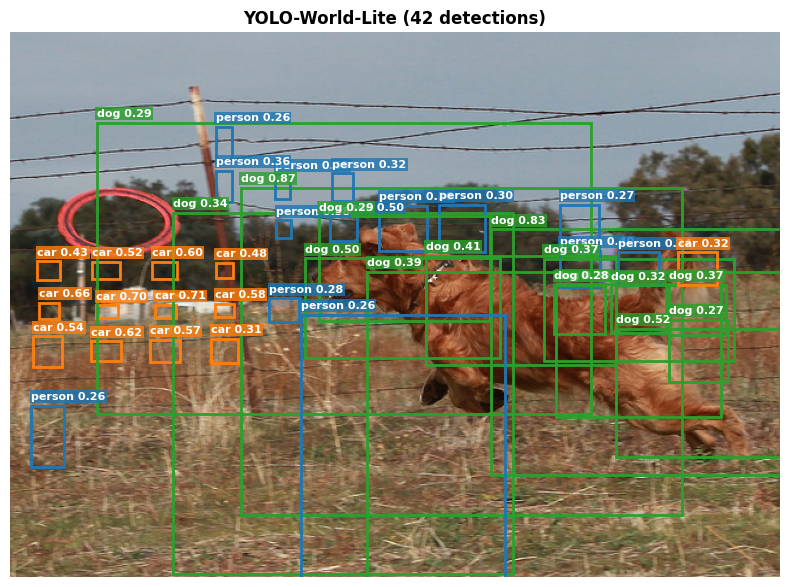

Saved: detection_2.png


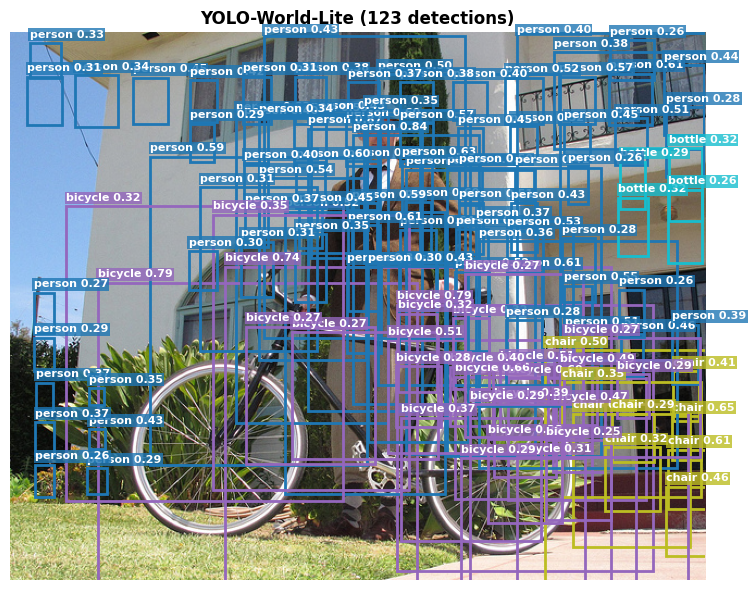

Saved: detection_3.png


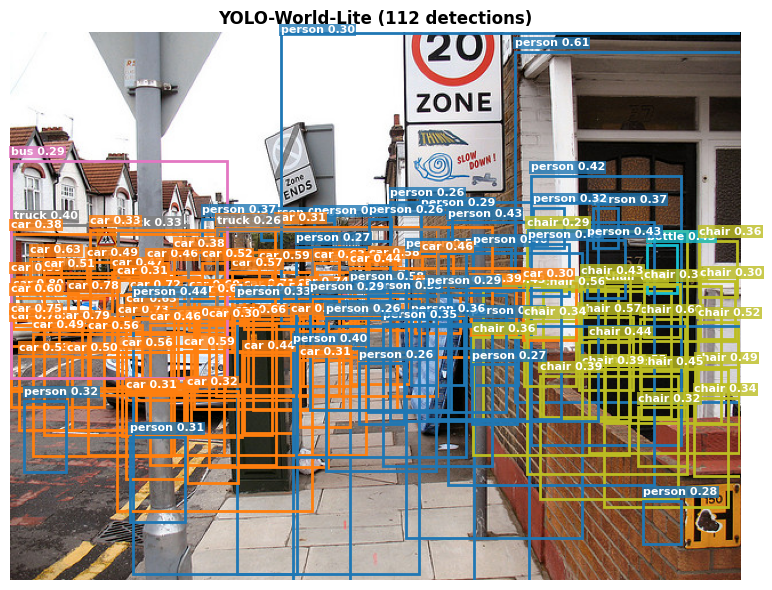

Saved: detection_4.png


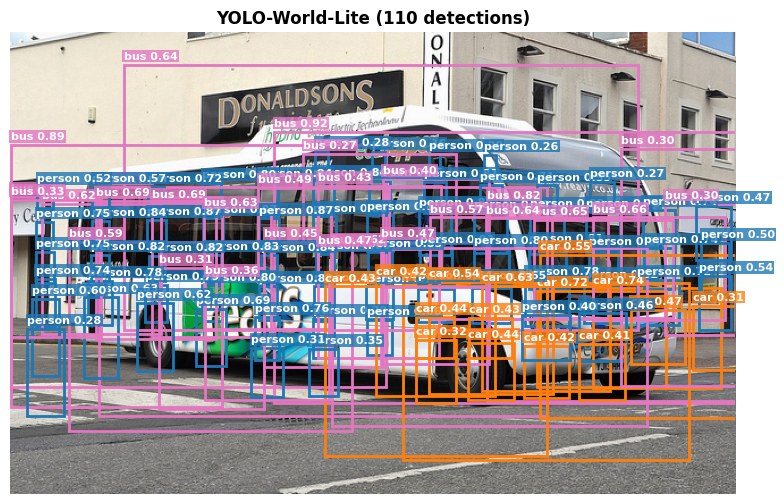

In [40]:
def show_detections(img_path, conf_thresh=0.30, save_path=None):
    img_tensor, img_pil = preprocess_image(img_path)
    W, H = img_pil.size

    with torch.no_grad():
        box_p, obj_p, cls_p = model(img_tensor, text_embeddings)

    detections = decode_predictions(box_p, obj_p, cls_p, conf_thresh=conf_thresh)
    dets = detections[0]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img_pil)
    ax.set_title(f'YOLO-World-Lite ({len(dets)} detections)', fontsize=12, fontweight='bold')
    ax.axis('off')

    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    for (x1, y1, x2, y2), score, cls_id in dets:
        cls_id = int(cls_id)
        color  = colors[cls_id]
        px1, py1 = x1 * W, y1 * H
        pw,  ph  = (x2 - x1) * W, (y2 - y1) * H
        rect = patches.Rectangle((px1, py1), pw, ph,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = f"{IDX_TO_CLASS[cls_id]} {score:.2f}"
        ax.text(px1, max(py1 - 5, 0), label, color='white', fontsize=8,
                fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# Show detections on 4 validation images
print("Qualitative detections from YOLO-World-Lite (trained from scratch):")
for i in range(4):
    img_path = f"coco/images/{img_id_to_info[ok_val[i]]['file_name']}"
    show_detections(img_path, conf_thresh=0.25, save_path=f'detection_{i+1}.png')

---
## STEP 10: Quantitative Evaluation — Recall@1
---

In [41]:
# Evaluate recall per class on val set
# Recall@1 = fraction of images where at least 1 correct class is detected

model.eval()
class_correct = {c: 0 for c in TARGET_CLASSES}
class_total   = {c: 0 for c in TARGET_CLASSES}

with torch.no_grad():
    for img_id in ok_val[:100]:  # evaluate on first 100 val images (fast)
        fname    = img_id_to_info[img_id]['file_name']
        img_path = f'coco/images/{fname}'
        if not os.path.exists(img_path):
            continue

        img_tensor, _ = preprocess_image(img_path)
        box_p, obj_p, cls_p = model(img_tensor, text_embeddings)
        dets = decode_predictions(box_p, obj_p, cls_p, conf_thresh=0.25)[0]

        # Ground truth classes in this image
        gt_classes = set()
        for ann in img_to_anns.get(img_id, []):
            cname = cat_id_to_name.get(ann['category_id'])
            if cname in CLASS_TO_IDX:
                gt_classes.add(cname)

        # Predicted classes
        pred_classes = set()
        for _, score, cls_id in dets:
            pred_classes.add(IDX_TO_CLASS[int(cls_id)])

        for cls in gt_classes:
            class_total[cls]   += 1
            if cls in pred_classes:
                class_correct[cls] += 1

print("\nRecall@1 per class (our model, trained from scratch):")
print("-" * 45)
recall_scores = {}
for cls in TARGET_CLASSES:
    if class_total[cls] > 0:
        r = class_correct[cls] / class_total[cls]
    else:
        r = 0.0
    recall_scores[cls] = r
    print(f"  {cls:20s}: {r:.2f}  ({class_correct[cls]}/{class_total[cls]})")

mean_recall = np.mean(list(recall_scores.values()))
print(f"\n  Mean Recall@1: {mean_recall:.2f}")


Recall@1 per class (our model, trained from scratch):
---------------------------------------------
  person              : 1.00  (83/83)
  car                 : 1.00  (11/11)
  dog                 : 0.86  (6/7)
  cat                 : 1.00  (4/4)
  bicycle             : 0.50  (2/4)
  motorcycle          : 1.00  (1/1)
  bus                 : 1.00  (4/4)
  truck               : 1.00  (2/2)
  chair               : 1.00  (7/7)
  bottle              : 1.00  (10/10)

  Mean Recall@1: 0.94


---
## STEP 11: Open-Vocabulary Test (Novel Classes)
Key test: since we use CLIP text embeddings, we can query classes NOT seen during training.
This demonstrates YOLO-World's core open-vocabulary capability — even in our lite version.
---

Saved: ovd_test_standard.png


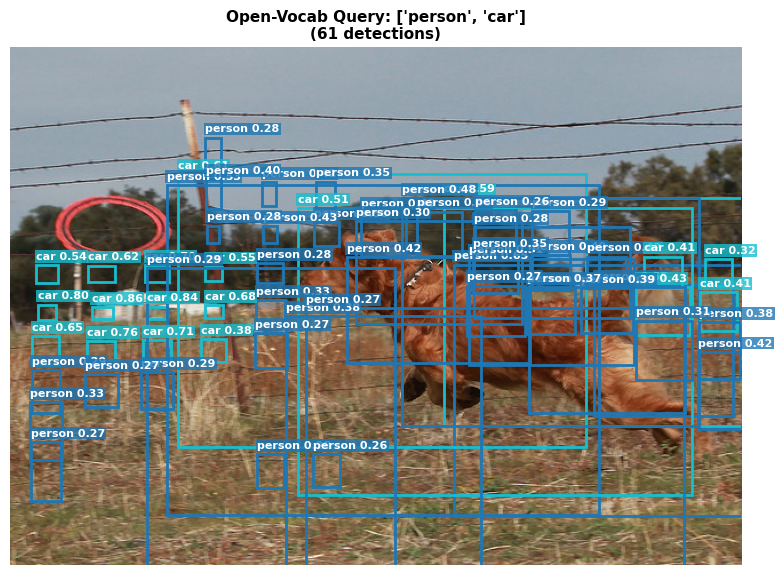

Saved: ovd_test_novel.png


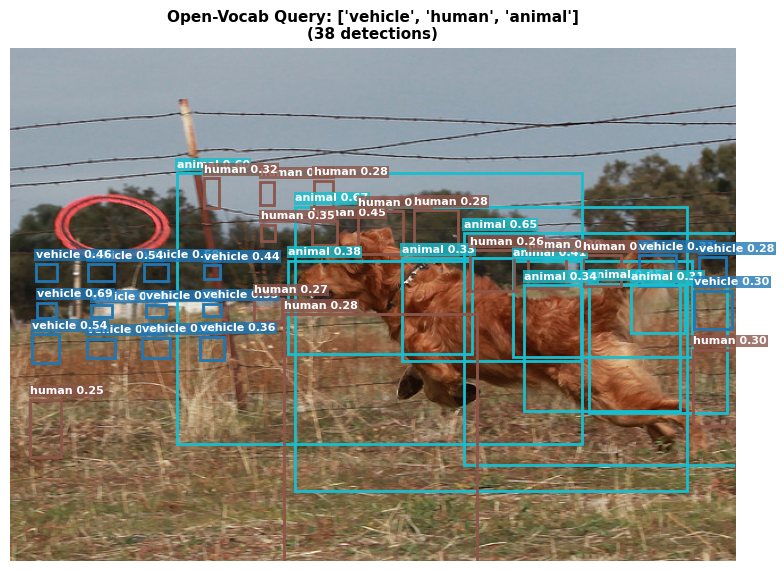

In [42]:
def infer_with_custom_query(img_path, custom_classes, conf_thresh=0.25, save_path=None):
    """
    Test open-vocabulary capability: query any class name,
    even ones not in the 10 training classes.
    Works because we use CLIP embeddings — same mechanism as YOLO-World.
    """
    # Encode custom classes with CLIP on the fly
    with torch.no_grad():
        prompts   = [f'a photo of a {c}' for c in custom_classes]
        tokens    = clip.tokenize(prompts).to(device)
        custom_te = clip_model.encode_text(tokens)
        custom_te = F.normalize(custom_te.float(), dim=-1)

    img_tensor, img_pil = preprocess_image(img_path)
    W, H = img_pil.size

    with torch.no_grad():
        # FIX 3 (cont.): model.forward now infers C from custom_te.shape[0]
        # so any number of custom classes works without errors.
        box_p, obj_p, cls_p = model(img_tensor, custom_te)

    dets = decode_predictions(box_p, obj_p, cls_p, conf_thresh=conf_thresh)[0]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img_pil)
    ax.set_title(f'Open-Vocab Query: {custom_classes}\n({len(dets)} detections)',
                 fontsize=11, fontweight='bold')
    ax.axis('off')

    colors = plt.cm.tab10(np.linspace(0, 1, len(custom_classes)))
    for (x1, y1, x2, y2), score, cls_id in dets:
        cls_id = int(cls_id)
        color  = colors[cls_id % len(colors)]
        px1, py1 = x1 * W, y1 * H
        pw,  ph  = (x2 - x1) * W, (y2 - y1) * H
        rect = patches.Rectangle((px1, py1), pw, ph,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = f"{custom_classes[cls_id]} {score:.2f}"
        ax.text(px1, max(py1 - 5, 0), label, color='white', fontsize=8,
                fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


test_img = f"coco/images/{img_id_to_info[ok_val[0]]['file_name']}"

# Test with standard classes
infer_with_custom_query(test_img, ['person', 'car'], save_path='ovd_test_standard.png')

# Test with novel classes (not in training set) — this is the open-vocab capability
infer_with_custom_query(test_img, ['vehicle', 'human', 'animal'],
                        save_path='ovd_test_novel.png')

---
## STEP 12: Save Results Table for Report
---

In [43]:
# Save recall table
with open('recall_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Class', 'Correct', 'Total', 'Recall@1'])
    for cls in TARGET_CLASSES:
        writer.writerow([cls, class_correct[cls], class_total[cls],
                         round(recall_scores[cls], 3)])
    writer.writerow(['MEAN', '', '', round(mean_recall, 3)])

# FIX 6 (cont.): Use ACTUAL_EPOCHS so CSV loop doesn't IndexError
# if early stopping fired before NUM_EPOCHS
with open('training_history.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch', 'Train Loss', 'Val Loss',
                     'Train Obj', 'Val Obj',
                     'Train Box', 'Val Box',
                     'Train Cls', 'Val Cls'])
    for i in range(ACTUAL_EPOCHS):
        writer.writerow([
            i + 1,
            round(history['train_loss'][i], 4),
            round(history['val_loss'][i],   4),
            round(history['train_obj'][i],  4),
            round(history['val_obj'][i],    4),
            round(history['train_box'][i],  4),
            round(history['val_box'][i],    4),
            round(history['train_cls'][i],  4),
            round(history['val_cls'][i],    4),
        ])

print("Saved: recall_results.csv")
print("Saved: training_history.csv")

print("\n" + "="*60)
print("ALL OUTPUT FILES FOR SUBMISSION:")
print("="*60)
print("  best_model.pth         → trained model weights")
print("  training_curves.png    → Slide 3 / Report Section 3")
print("  detection_1-4.png      → Slide 3 qualitative results")
print("  ovd_test_standard.png  → open-vocab standard classes")
print("  ovd_test_novel.png     → open-vocab novel classes")
print("  recall_results.csv     → Table 1 in report")
print("  training_history.csv   → Table 2 in report")
print("="*60)

Saved: recall_results.csv
Saved: training_history.csv

ALL OUTPUT FILES FOR SUBMISSION:
  best_model.pth         → trained model weights
  training_curves.png    → Slide 3 / Report Section 3
  detection_1-4.png      → Slide 3 qualitative results
  ovd_test_standard.png  → open-vocab standard classes
  ovd_test_novel.png     → open-vocab novel classes
  recall_results.csv     → Table 1 in report
  training_history.csv   → Table 2 in report
